# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')


## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

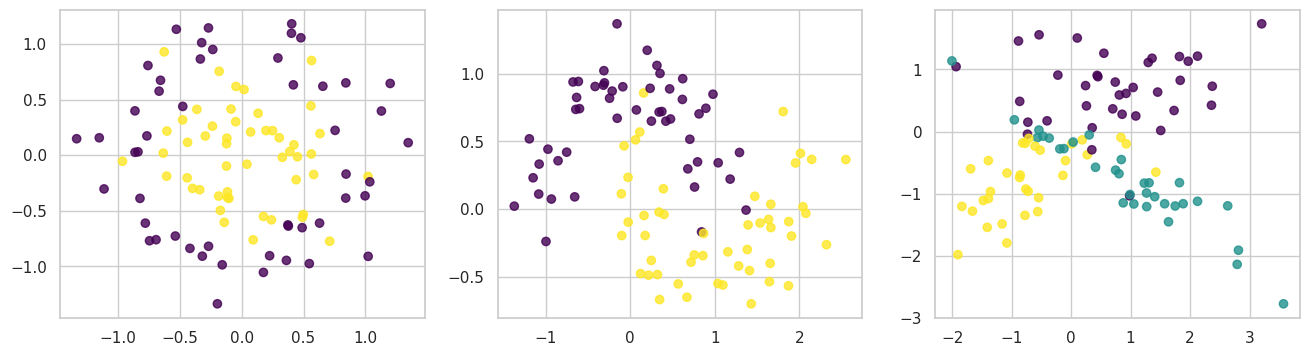

In [ ]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

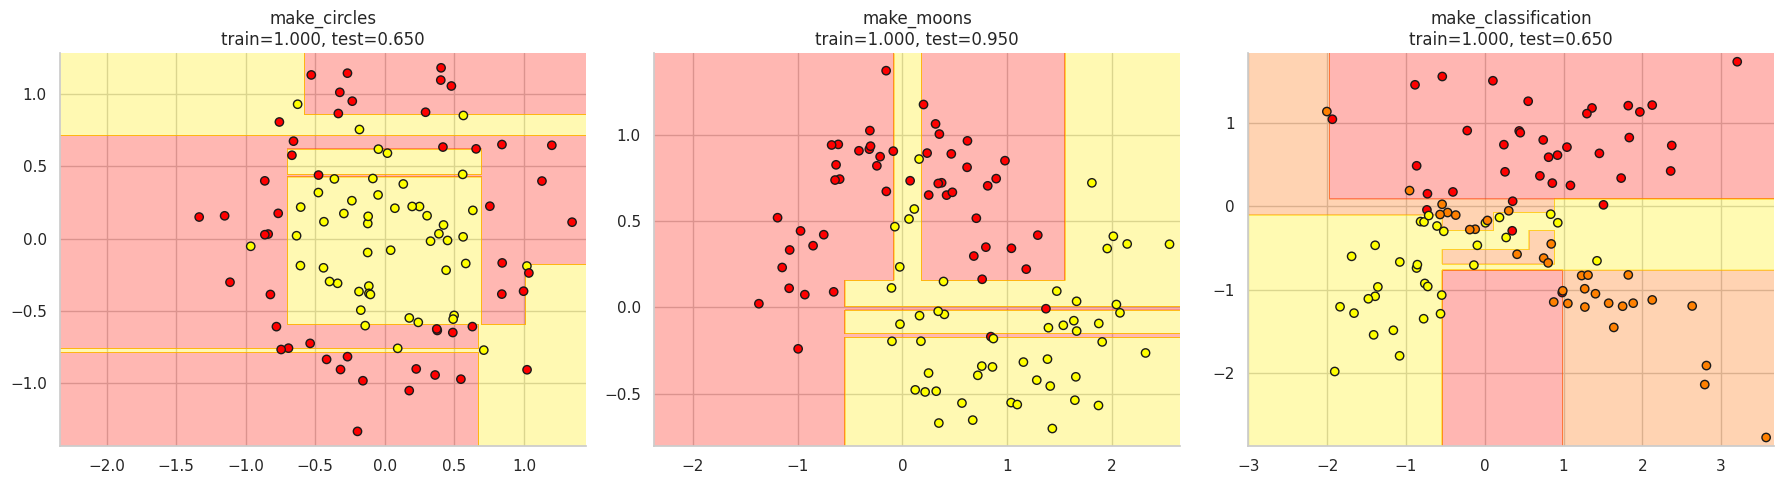

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
dataset_names = ['make_circles', 'make_moons', 'make_classification']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    X, y = datasets[i]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)

    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                         np.linspace(y_min, y_max, 1000))

    z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[i].contourf(xx, yy, z, alpha=0.3, cmap=plt.cm.autumn)
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.autumn, edgecolor='k')
    axes[i].set_title(f'{dataset_names[i]}\ntrain={train_acc:.3f}, test={test_acc:.3f}')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

__Ответ:__ Во всех случаях модель достигает train accuracy = 1.0 - она запоминает каждый объект обучающей выборки. Но на тесте качество заметно падает на make_circles и make_classification. Дерево строит слишком сложную границу с мелкими прямоугольными областями, которая описывает трейн, но не обобщается на новые данные. На make_moons переобучение меньше, так как данные в этом датасете лучше линейно разделимы

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

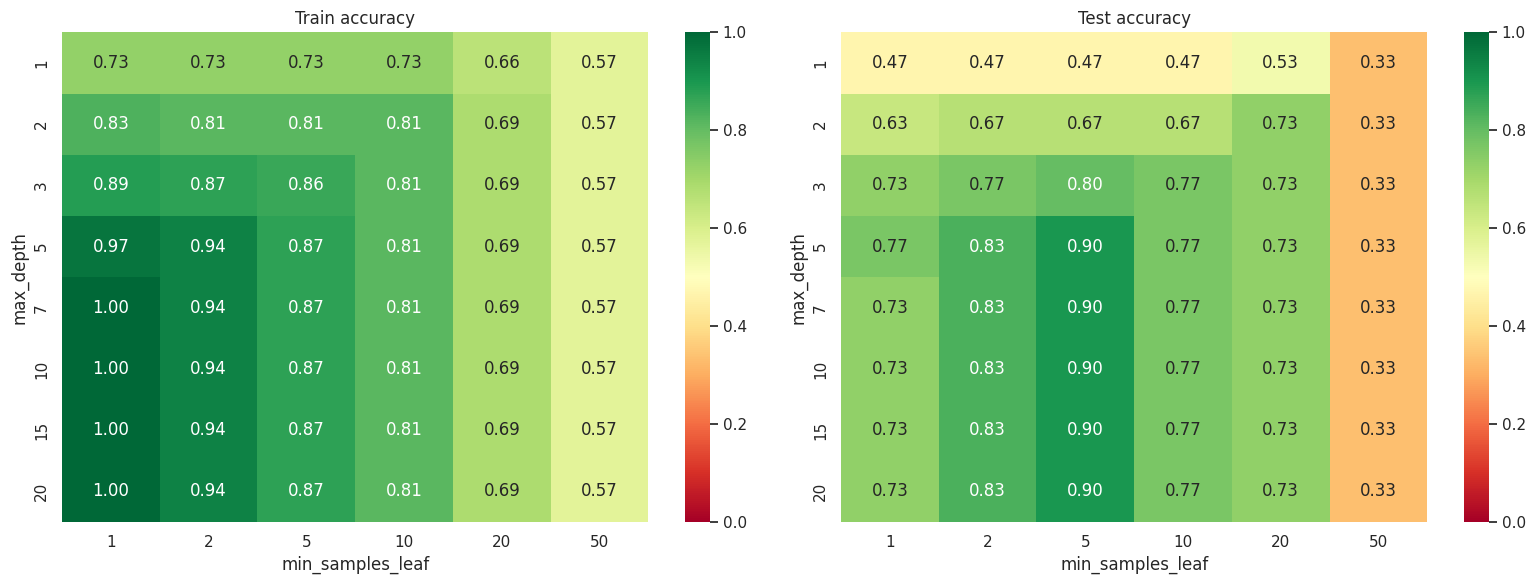

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
X, y = datasets[0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

max_depths = [1, 2, 3, 5, 7, 10, 15, 20]
min_samples_leafs = [1, 2, 5, 10, 20, 50]

train_results = np.zeros((len(max_depths), len(min_samples_leafs)))
test_results = np.zeros((len(max_depths), len(min_samples_leafs)))

for i in range(len(max_depths)):
    for j in range(len(min_samples_leafs)):
        tree = DecisionTreeClassifier(max_depth=max_depths[i], min_samples_leaf=min_samples_leafs[j], random_state=42)
        tree.fit(X_train, y_train)
        train_results[i, j] = tree.score(X_train, y_train)
        test_results[i, j] = tree.score(X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(train_results, annot=True, fmt='.2f',
            xticklabels=min_samples_leafs,
            yticklabels=max_depths,
            ax=axes[0], cmap='RdYlGn', vmin=0, vmax=1)

axes[0].set_title('Train accuracy')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(test_results, annot=True, fmt='.2f',
            xticklabels=min_samples_leafs,
            yticklabels=max_depths,
            ax=axes[1], cmap='RdYlGn', vmin=0, vmax=1)

axes[1].set_title('Test accuracy')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')

plt.tight_layout()
plt.show()

__Ответ:__ Испольовал гиперпараметры max_depth и min_samples_leaf на датасете make_circles. Лучшее соотношение смещения и разброса достигается при min_samples_leaf = 5 и max_depth >= 5 (test accuracy=0.9). При min_samples_leaf=1 и большой глубине модель переобучается: train=1.0, но test падает до 0.73. При min_samples_leaf=50 модель недообучается - слишком много объектов в листе не позволяет дереву уловить структуру данных. Увеличение max_depth ухудшило модель только в одном случае при min_samples_leaf=1 при переходе с 5 на 7, это объясняется тем, что при min_samples_leaf=1 в дереве может быть много листьев и до глубины = 5 модель не успевает переобучиться, а далее начинает запоминать шум. Во всех остальных случаях увеличение глубины не ухудшало или улучшало модель (максимальная глубина иногда не достигается, так как точки заканчиваются раньше, из-за чего иногда нет разницы между максимальной глубиной 5 и 20)

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

In [ ]:
def find_best_split(feature_vector, target_vector):
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов нужно брать среднее двух соседних при сортировке значений признака
    * Поведение функции в случае константного признака может быть любым
    * При одинаковых приростах критерия Джини для нескольких порогов нужно выбирать сплит, у которого значение порога минимально
    * Достаточно поддерживать только бинарную классификацию.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов, len(feature_vector) == len(target_vector)

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно разделить на две различные подвыборки или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds, len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    sorted_i = np.argsort(feature_vector)
    feature_sorted = feature_vector[sorted_i]
    target_sorted = target_vector[sorted_i]

    n = len(feature_vector)

    change_i = np.where(feature_sorted[:-1] != feature_sorted[1:])[0]
    if len(change_i) == 0:
        return np.array([]), np.array([]), None, None

    thresholds = (feature_sorted[change_i] + feature_sorted[change_i + 1]) / 2
    cumsum = np.cumsum(target_sorted)
    ones_left = cumsum[change_i]
    n_left = change_i + 1
    n_right = n - n_left
    ones_right = cumsum[-1] - ones_left

    p1_left = ones_left / n_left
    p0_left = 1 - p1_left
    p1_right = ones_right / n_right
    p0_right = 1 - p1_right

    gini_left = 1 - p1_left ** 2 - p0_left ** 2
    gini_right = 1 - p1_right ** 2 - p0_right ** 2

    ginis = -(n_left / n) * gini_left - (n_right / n) * gini_right

    best_i = np.argmax(ginis)
    threshold_best = thresholds[best_i]
    gini_best = ginis[best_i]

    return thresholds, ginis, threshold_best, gini_best


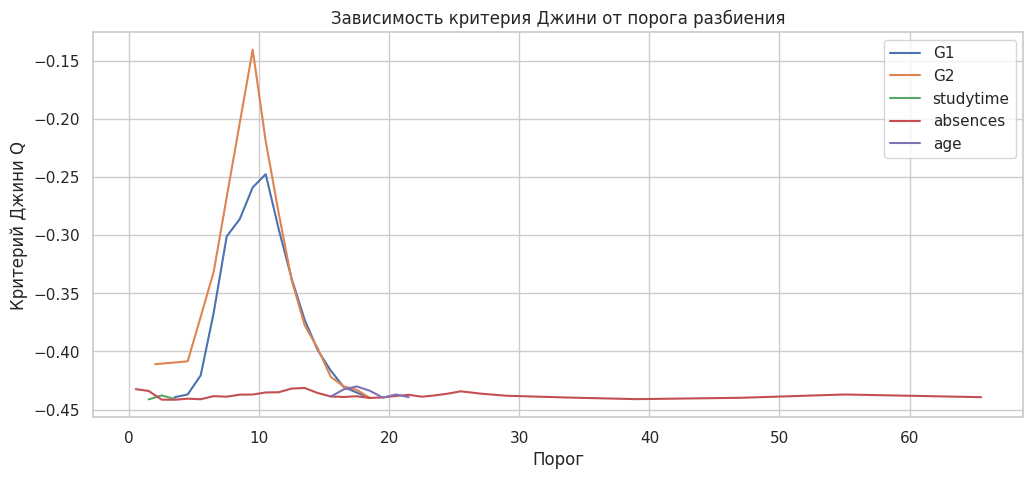

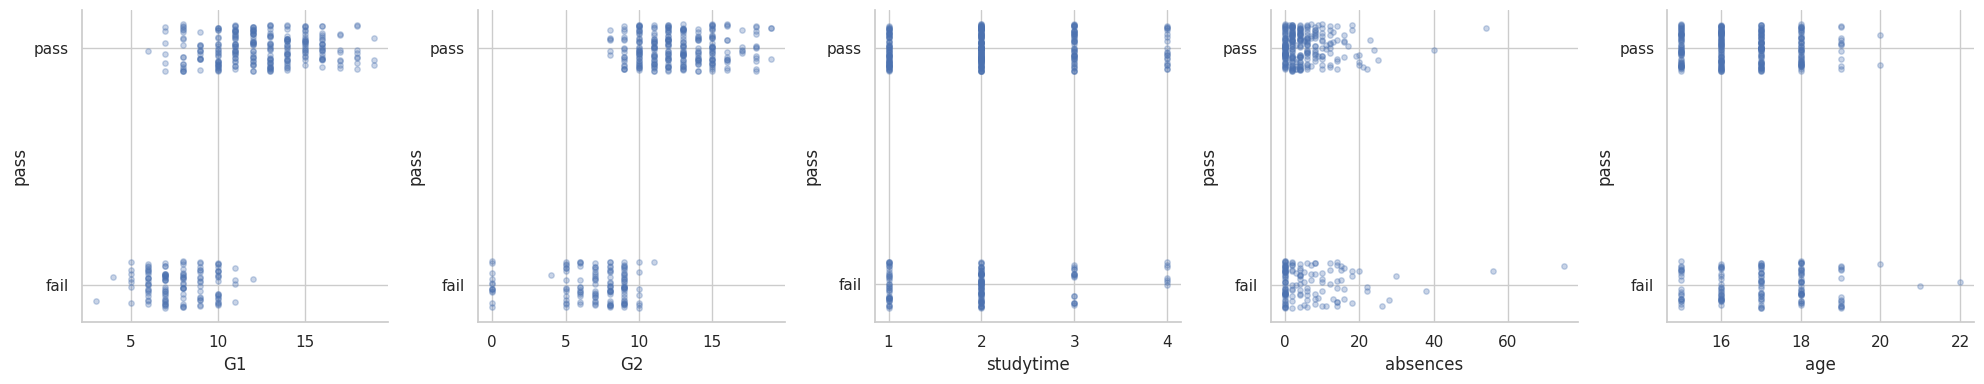

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
#у меня нет доступа к интернету в кагле, надо подтвердить номер, иностранного у меня нет
#сейчас разбираться долго
#в итоге просто скачал датасет с сайта, загрузил в кагл и использовал локальный путь
#можете попробовать у себя запустить вот это ->
# !pip install ucimlrepo
# from ucimlrepo import fetch_ucirepo
# student_performance = fetch_ucirepo(id=320)
# df = student_performance.data.original
#это код с сайта для импорта в питон

df = pd.read_csv('/kaggle/input/datasets/alexetmercedes/student-mat-csv/student-mat.csv', sep=';')
df['pass'] = (df['G3'] >= 10).astype(int)
features = ['G1', 'G2', 'studytime', 'absences', 'age']
y = df['pass'].values

plt.figure(figsize=(12, 5))
for feat in features:
    feature_vector = df[feat].values
    thresholds, ginis, threshold_best, gini_best = find_best_split(feature_vector, y)
    plt.plot(thresholds, ginis, label=feat)

plt.xlabel('Порог')
plt.ylabel('Критерий Джини Q')
plt.title('Зависимость критерия Джини от порога разбиения')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    feature_vector = df[features[i]].values
    jitter = np.random.uniform(-0.1, 0.1, size=len(y))
    axes[i].scatter(feature_vector, y + jitter, alpha=0.3, s=15)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('pass')
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['fail', 'pass'])
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

__Ответ:__ G1 и G2 - ожидаемо информативные, так как студент, который учился хорошо ранее - сдаст, тот, кто плохо учился - нет

studytime - умеренно информативный - проследим, насколько играет роль, неочевидно

absences и age - потенциально неинформативные, так как пропускающий студент может либо все знать, либо не знать ничего, а возраст очевидно никак не влияет.

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**
1. По G2 - у него пик критерия Джини наиболее близок к нулю. Чем ближе Q к нулю, тем чище разбиение - левое поддерево будет почти полностью из fail, а правое из pass
2. Да, на scatter графике G2 видно, что низкие значения почти все fail, а высокие поти все pass. Похожая ситуация и для G1, но некоторые люди с низкими баллами оказались pass. А для studytime, absences, age точки обоих классов перемешаны по всей оси X - разделить их сложно, что и подтверждают плоские кривые Джини
3. Для информативных признаков кривые имеют выраженный пик - Q возрастает и приближается к нулю. Значит существует порог, который хорошо разделяет классы.
  
   Для неинформативных признаков кривые почти плоские, нет порога, который заметно улучшил бы разбиение. При этом эти признаки на уровне приблизительно -0.43, а -0.43 это примерно значение Джини для исходной несбалансированной выборки без какого-либо разбиения

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [ ]:
from collections import Counter
import numpy as np


class DecisionTree:
    """
    Простое классификационное дерево, поддерживающее:
    * real / categorical признаки
    * binary цели (метки могут быть числами или строками)
    * ограничения max_depth, min_samples_split, min_samples_leaf (как в sklearn по смыслу)

    ВНИМАНИЕ: в методе _fit_node ниже могут быть намеренно оставлены некоторые ошибки.
    Их нужно исправить в рамках задания.
    """
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node):
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(0, sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])
                ratio = {}
                for key, current_count in counts.items():
                    if key in clicks:
                        current_click = clicks[key]
                    else:
                        current_click = 0
                    ratio[key] = current_click / current_count
                sorted_categories = list(map(lambda x: x[0], sorted(ratio.items(), key=lambda x: x[1])))
                categories_map = dict(zip(sorted_categories, list(range(len(sorted_categories)))))

                feature_vector = np.array(list(map(lambda x: categories_map[x], sub_X[:, feature])))
            else:
                raise ValueError

            if len(feature_vector) == 3:
                continue

            _, _, threshold, gini = find_best_split(feature_vector, sub_y)
            if threshold is None:
                continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini
                split = feature_vector < threshold

                if feature_type == "real":
                    threshold_best = threshold
                elif feature_type == "categorical":
                    threshold_best = list(map(lambda x: x[0],
                                              filter(lambda x: x[1] < threshold, categories_map.items())))
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["categories_split"] = threshold_best
        else:
            raise ValueError
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        if self._feature_types[feature] == "real":
            if x[feature] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])


    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
#тут сделаю так же, как и в задании 4, смотри выше
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
df_mushrooms = pd.read_csv(
    '/kaggle/input/datasets/alexetmercedes/agaricus-lepiota-data/agaricus-lepiota.data',
    header=None
)
for col in df_mushrooms.columns:
    df_mushrooms[col] = LabelEncoder().fit_transform(df_mushrooms[col])

X_mush = df_mushrooms.iloc[:, 1:].values
y_mush = df_mushrooms.iloc[:, 0].values

feature_types = ['categorical'] * X_mush.shape[1]

X_train_mush, X_test_mush, y_train_mush, y_test_mush = train_test_split(
    X_mush, y_mush, test_size=0.5, random_state=42
)

tree_mush = DecisionTree(feature_types=feature_types)
tree_mush.fit(X_train_mush, y_train_mush)

y_pred_mush = tree_mush.predict(X_test_mush)
print(f'Accuracy: {accuracy_score(y_test_mush, y_pred_mush):.4f}')

Accuracy: 1.0000


__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [ ]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
red = pd.read_csv('/kaggle/input/datasets/alexetmercedes/winequality/winequality-red.csv', sep=';')
white = pd.read_csv('/kaggle/input/datasets/alexetmercedes/winequality/winequality-white.csv', sep=';')
red['color'] = 0
white['color'] = 1

In [ ]:
df = pd.concat([red, white], ignore_index=True)
df = df.sample(frac=0.1) #сэмплирование вот, переделал код в силу обстоятельств

X = df.drop(columns=['color'])
y = df['color']


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 1741 to 1843
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         650 non-null    float64
 1   volatile acidity      650 non-null    float64
 2   citric acid           650 non-null    float64
 3   residual sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free sulfur dioxide   650 non-null    float64
 6   total sulfur dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
Index: 650 entries, 5089 to 5612
Series name: color
Non-Null Count  Dtype
--------------  -----
650 non-null    int64
dtypes: int64(1)
memory usage: 10.2 KB


In [ ]:
class DecisionTree:
    """
    Простое классификационное дерево, поддерживающее:
    * real / categorical признаки
    * binary цели (метки могут быть числами или строками)
    * ограничения max_depth, min_samples_split, min_samples_leaf (как в sklearn по смыслу)

    ВНИМАНИЕ: в методе _fit_node ниже могут быть намеренно оставлены некоторые ошибки.
    Их нужно исправить в рамках задания.
    """
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if self._max_depth is not None and depth >= self._max_depth:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        if self._min_samples_split is not None and len(sub_y) < self._min_samples_split:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(0, sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])
                ratio = {}
                for key, current_count in counts.items():
                    if key in clicks:
                        current_click = clicks[key]
                    else:
                        current_click = 0
                    ratio[key] = current_click / current_count
                sorted_categories = list(map(lambda x: x[0], sorted(ratio.items(), key=lambda x: x[1])))
                categories_map = dict(zip(sorted_categories, list(range(len(sorted_categories)))))

                feature_vector = np.array(list(map(lambda x: categories_map[x], sub_X[:, feature])))
            else:
                raise ValueError

            if len(feature_vector) == 3:
                continue

            _, _, threshold, gini = find_best_split(feature_vector, sub_y)
            if threshold is None:
                continue

            if self._min_samples_leaf is not None:
                left_count = np.sum(feature_vector < threshold)
                right_count = len(feature_vector) - left_count
                if left_count < self._min_samples_leaf or right_count < self._min_samples_leaf:
                    continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini
                split = feature_vector < threshold

                if feature_type == "real":
                    threshold_best = threshold
                elif feature_type == "categorical":
                    threshold_best = list(map(lambda x: x[0],
                                              filter(lambda x: x[1] < threshold, categories_map.items())))
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["categories_split"] = threshold_best
        else:
            raise ValueError
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"], depth + 1)

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        if self._feature_types[feature] == "real":
            if x[feature] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])


    def fit(self, X, y):
        self._fit_node(X, y, self._tree, depth=0)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
X = X.values
y = y.values
feature_types = ['real'] * X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

tree1 = DecisionTree(feature_types=feature_types)
tree1.fit(X_train, y_train)
print('Дерево без параметров:')
print(classification_report(y_test, tree1.predict(X_test)))

tree2 = DecisionTree(feature_types=feature_types, max_depth=8, min_samples_leaf=5, min_samples_split=17)
tree2.fit(X_train, y_train)
print('Дерево с параметрами:')
print(classification_report(y_test, tree2.predict(X_test)))

tree_sklearn = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=17, random_state=0)
tree_sklearn.fit(X_train, y_train)
print('sklearn дерево с параметрами:')
print(classification_report(y_test, tree_sklearn.predict(X_test)))

Дерево без параметров:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        60
           1       0.97      0.99      0.98       135

    accuracy                           0.97       195
   macro avg       0.97      0.96      0.96       195
weighted avg       0.97      0.97      0.97       195

Дерево с параметрами:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        60
           1       0.99      0.99      0.99       135

    accuracy                           0.98       195
   macro avg       0.98      0.98      0.98       195
weighted avg       0.98      0.98      0.98       195

sklearn дерево с параметрами:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        60
           1       0.99      0.99      0.99       135

    accuracy                           0.99       195
   macro avg       0.99      0.99      0.99       195

Дерево с параметрами показывает лучшее качество на тесте по сравнению с деревом без параметров. Без ограничений дерево переобучается - запоминает обучающую выборку целиком, что ухудшает обобщение на новых данных. Хоть на этих данных разница не столь ощутимая, но с рекомендованными параметрами модель работает лучше, переобучение снижается. Моя реализация с параметрами показывает результат близкий к sklearn, значит реализация корректная

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [ ]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(34.02269807504765)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [ ]:
def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = len(y)
    all_preds = np.full((n, num_runs), np.nan)
    for run in range(num_runs):
        bootstrap_i = np.random.choice(n, size=n, replace=True)
        oob_i = np.array(list(set(range(n)) - set(bootstrap_i)))

        if len(oob_i) == 0:
            continue

        model.fit(X[bootstrap_i], y[bootstrap_i])
        all_preds[oob_i, run] = model.predict(X[oob_i])
    mean_preds = np.nanmean(all_preds, axis=1)
    valid = ~np.all(np.isnan(all_preds), axis=1)
    bias = np.mean((mean_preds[valid] - y[valid]) ** 2)
    variance = np.mean(np.nanvar(all_preds[valid], axis=1))
    error = np.nanmean((all_preds[valid] - y[valid, None]) ** 2)
    return bias, variance, error

__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor()
}
for name, model in models.items():
    bias, variance, error = compute_biase_variance(model, X, y, num_runs=20)
    print(f'{name}:')
    print(f'  bias={bias:.4f}, variance={variance:.4f}, error={error:.4f}')
    print(f'  bias + variance = {bias + variance:.4f}')
    print()

/tmp/ipykernel_18929/3960283222.py:25: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(all_preds, axis=1)


LinearRegression:
  bias=0.5282, variance=0.0019, error=0.5290
  bias + variance = 0.5302



/tmp/ipykernel_18929/3960283222.py:25: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(all_preds, axis=1)


DecisionTree:
  bias=0.2829, variance=0.2556, error=0.5407
  bias + variance = 0.5385

RandomForest:
  bias=0.2491, variance=0.0160, error=0.2649
  bias + variance = 0.2651



/tmp/ipykernel_18929/3960283222.py:25: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(all_preds, axis=1)


**Ответ:** Хоть я использовал меньшее количество прогонов, но динамика уже понятна (запускал ранее на 100, по сути и градации точности результаты теже, только числа отличаются). Результаты согласуются с теорией из занятий. LinearRegression имеет высокое смещение и низкий разброс - простая модель стабильна и не улавливает нелинейности. DecisionTree имеет низкое смещение но высокий разброс - переобучение на выборке. RandomForest объединяет лучшее из двух: низкое смещение и низкий разброс за счет усреднения многих деревьев, но работает гораздо дольше.

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

**Ответ:** Бэггинг над деревом значительно снизил разброс, почти не изменив смещение. Такое поведение соответствует теоретическому. Для линейной регрессии бэггинг не помог - её разброс и так мал, а смещение бэггинг не уменьшает

In [ ]:
from sklearn.ensemble import BaggingRegressor

models_bagging = {
    'Bagging(LinearRegression)': BaggingRegressor(estimator=LinearRegression(), n_estimators=10, random_state=0),
    'Bagging(DecisionTree)': BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=0),
    'Bagging(RandomForest)': BaggingRegressor(estimator=RandomForestRegressor(), n_estimators=10, random_state=0),
}

for name, model in models_bagging.items():
    bias, variance, error = compute_biase_variance(model, X, y, num_runs=20)
    print(f'{name}:')
    print(f'  bias={bias:.4f}, variance={variance:.4f}, error={error:.4f}')
    print()

/tmp/ipykernel_18929/3960283222.py:25: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(all_preds, axis=1)


Bagging(LinearRegression):
  bias=0.6363, variance=0.0735, error=0.6545



/tmp/ipykernel_18929/3960283222.py:25: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(all_preds, axis=1)


Bagging(DecisionTree):
  bias=0.2539, variance=0.0393, error=0.2915



KeyboardInterrupt: 

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [ ]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title="", ax=None):
    """
    plot graphics described above
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    test_i = np.random.choice(len(y), size=num_test_objects, replace=False)
    train_i = np.array(list(set(range(len(y))) - set(test_i)))
    X_test, y_test = X[test_i], y[test_i]
    X_train, y_train = X[train_i], y[train_i]
    all_preds = np.zeros((num_test_objects, num_runs))

    for run in range(num_runs):
        boot_i = np.random.choice(len(y_train), size=len(y_train), replace=True)
        model.fit(X_train[boot_i], y_train[boot_i])
        all_preds[:, run] = model.predict(X_test)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    for i in range(num_test_objects):
        ax.scatter([i] * num_runs, all_preds[i], alpha=0.2, s=10,
                   color=plt.cm.tab10(i / num_test_objects))
        ax.scatter(i, y_test[i], color='black', s=50, zorder=5)

    ax.set_xlabel('Номер тестового объекта')
    ax.set_ylabel('Предсказание')
    ax.set_title(title)

    return all_preds, y_test

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_viz = [
    ('LinearRegression', LinearRegression()),
    ('DecisionTree', DecisionTreeRegressor()),
    ('RandomForest', RandomForestRegressor())
]

results = []
for i, (name, model) in enumerate(models_viz):
    preds, y_test = plot_predictions(model, X, y, num_runs=100, title=name, ax=axes[i])
    results.append((preds, y_test))

all_values = np.concatenate([p.ravel() for p, _ in results] + [r[1] for r in results])
y_min, y_max = all_values.min() - 0.1, all_values.max() + 0.1
for ax in axes:
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('task11_predictions.png', dpi=120, bbox_inches='tight')
plt.show()